# Homework №7

- Select a dependent variable and at least 7 independent variables (you can select more). Please note that there are variables that evaluate the
same indicator but are calculated differently. Please don't include them in the model at the same time.
- Formulate hypotheses about the existence of relationships between the dependent and independent variables.
- Conduct descriptive data analysis.
- Conduct tests to select one of three models: pulled regression model, model with fixed effects, and model with random effects. Choose the
right model and justify your choice.
- Describe the resulting model.
- Describe in detail the relationships between the dependent variable and each predictor.
- Draw conclusions from the analysis.

In [ ]:
!pip install linearmodels
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import roc_curve, auc, classification_report
from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings
import pandas as pd
from linearmodels import PanelOLS, RandomEffects
from linearmodels.panel import compare
import statsmodels.api as sm
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data Analysis/Worldbank_panel.xlsx')
df = df.set_index(["id", "year"])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = df.dropna()

## Descriptive analysis

In [ ]:
df.head()

v1          v2        v3         v4         v5  \
id        year                                                            
Algeria   2017    24.803750   6230157.0   74714.0   974345.0  3210267.0   
Argentina 2015   243.772567  14245183.0  145585.0  1700265.0  6855837.0   
          2016   254.181414  15076354.0  149334.0  1654692.0  7251673.0   
          2017   305.102000  16749271.0  146631.0  1765973.0  7842778.0   
Australia 2015  1907.051909  69779346.0  668961.0  7621017.0  6828000.0   

                       v6        v7         v8         v9           v10  ...  \
id        year                                                           ...   
Algeria   2017   7.756294   4100982   9.908341   0.960299  9.027398e+06  ...   
Argentina 2015  15.915893  10073125  23.384858   9.225692  1.475176e+09  ...   
          2016  16.667271  10164849  23.362925   8.982391  1.333426e+09  ...   
          2017  17.849997   9744368  22.177975   9.205419  1.487360e+09  ...   
Australia 2015  28.530239   8500000  35.516554  19.685314  5.089628e+09  ...   

                    v29           v30        v31        v32        v33  \
id        year                                                           
Algeria   2017   8883.0   4192.337692  38.486829  42.562759  18.950412   
Argentina 2015  66278.0  13789.060425  15.995783  65.905837  18.098380   
          2016  71058.0  13360.211835  16.623530  65.721891  17.654578   
          2017  74722.0  13595.037355  15.563533  66.739573  17.696894   
Australia 2015  70760.0  56707.022077  24.796098  56.855164  18.348738   

                      v34        v35        v36   v37     v38  
id        year                                                 
Algeria   2017  22.632232  32.689171   6.279384  24.3  76.499  
Argentina 2015  10.705652  11.780574  10.229339  11.5  76.068  
          2016  12.527095  13.566793   9.001897  10.9  76.221  
          2017  11.320283  13.969318  10.442255  10.3  76.372  
Australia 2015  20.069283  21.556339   9.327589   3.9  82.400  

[5 rows x 38 columns]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 204 entries, ('Algeria', 2017) to ('United States', 2018)
Data columns (total 38 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   v1      204 non-null    float64
 1   v2      204 non-null    float64
 2   v3      204 non-null    float64
 3   v4      204 non-null    float64
 4   v5      204 non-null    float64
 5   v6      204 non-null    float64
 6   v7      204 non-null    int64  
 7   v8      204 non-null    float64
 8   v9      204 non-null    float64
 9   v10     204 non-null    float64
 10  v11     204 non-null    float64
 11  v12     204 non-null    float64
 12  v13     204 non-null    float64
 13  v14     204 non-null    float64
 14  v15     204 non-null    float64
 15  v16     204 non-null    float64
 16  v17     204 non-null    float64
 17  v18     204 non-null    float64
 18  v19     204 non-null    float64
 19  v20     204 non-null    float64
 20  v21     204 non-null    float64
 21  v22

In [ ]:
df.describe()

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v29,v30,v31,v32,v33,v34,v35,v36,v37,v38
count,204.000000,2.040000e+02,2.040000e+02,2.040000e+02,2.040000e+02,204.000000,2.040000e+02,204.000000,204.000000,2.040000e+02,...,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2311.173574,5.000072e+07,4.813156e+05,6.912844e+06,9.040863e+06,18.527192,1.143861e+07,22.444784,12.336693,2.491304e+10,...,51040.068627,18967.012579,21.920900,61.508298,16.570805,39.430344,41.269268,7.164832,14.302941,76.224532
std,5959.045524,1.196615e+08,1.350563e+06,9.848152e+06,1.694744e+07,13.008857,2.031732e+07,15.660322,11.053020,4.853520e+10,...,78127.241585,19391.303703,10.729275,11.067667,4.080582,25.607329,22.091403,2.646330,16.340584,5.467803
min,0.000000,2.603100e+04,9.970000e+02,7.350142e+02,2.369400e+04,0.097771,6.300600e+04,0.213609,0.181795,5.525120e+05,...,1819.000000,467.235432,-1.944767,34.534164,5.404240,8.257320,11.780574,2.639473,2.100000,57.206000
25%,15.654073,3.152248e+06,4.094425e+04,4.723990e+05,6.332122e+05,7.445381,8.021895e+05,9.881649,5.054166,2.115121e+08,...,7532.250000,4293.880112,16.375608,54.605577,13.813294,25.689546,26.466914,5.238558,4.300000,74.093000
50%,421.406602,1.319511e+07,1.277950e+05,3.184550e+06,2.471917e+06,15.855748,3.393518e+06,17.990709,9.114774,1.941341e+09,...,22706.500000,11040.928001,22.292620,60.317067,16.767936,33.682515,38.677148,7.164417,8.650000,76.387500
75%,1760.873824,6.745099e+07,5.295790e+05,9.772579e+06,9.753368e+06,29.206861,1.113528e+07,35.049857,17.810547,1.603267e+10,...,58076.750000,30398.873387,27.801992,66.633214,19.307912,46.939964,54.088419,8.920068,15.550000,81.132317
max,42985.299596,8.890240e+08,9.880509e+06,5.477634e+07,1.107560e+08,46.319901,1.248480e+08,58.673181,53.269670,2.097227e+11,...,464833.000000,87980.670685,55.465775,88.123919,26.362854,178.384608,151.086790,16.844324,84.000000,84.210976


## Selected variables

**Dependent Variable:**

- v30 (GDP per capita, constant 2015 US$)

**Independent Variables:**
- v6: Fixed Broadband Subscriptions
- v9: High-technology Exports as % of Manufactured Exports
- v14: ICT service exports (BoP, current US$)
- v31: Gross domestic savings (% of GDP)
- v36: Current health expenditure (% of GDP)
- v37: Mortality rate, under-5 (per 1,000 live births)
- v38: Life expectancy at birth, total (years)

## Analysis of selected variables

### Dependent variable

In [ ]:
df['v30'].describe()

,v30
count,204.000000
mean,18967.012579
std,19391.303703
min,467.235432
25%,4293.880112
50%,11040.928001
75%,30398.873387
max,87980.670685


<Axes: >

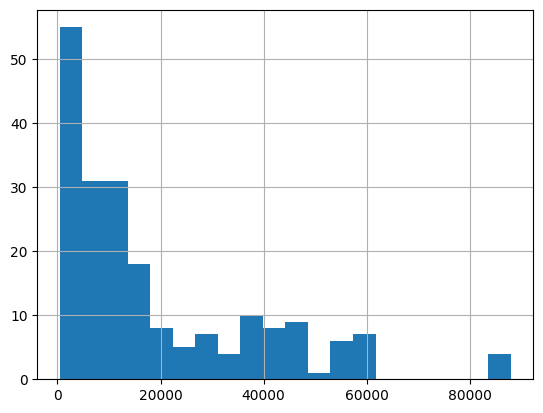

In [ ]:
df['v30'].hist(bins=20)

<Axes: xlabel='year'>

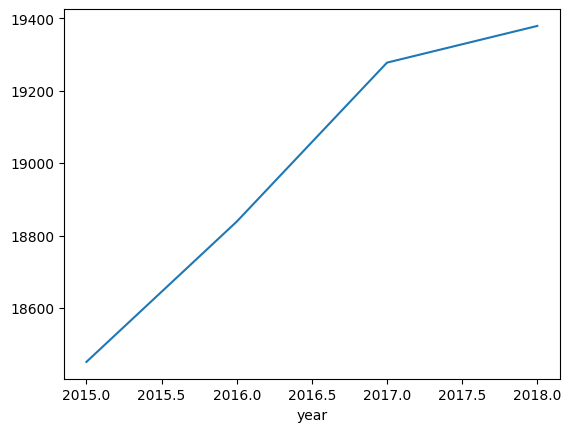

In [ ]:
df.groupby('year')['v30'].mean().plot()

### Inependent variables

#### v6: Fixed Broadband Subscriptions

Value Counts:
v6
7.756294     1
6.354836     1
0.157422     1
0.167442     1
0.215159     1
            ..
37.680133    1
38.537233    1
40.259216    1
1.293189     1
33.860368    1
Name: count, Length: 204, dtype: int64

Statistical Description:
count    204.000000
mean      18.527192
std       13.008857
min        0.097771
25%        7.445381
50%       15.855748
75%       29.206861
max       46.319901
Name: v6, dtype: float64


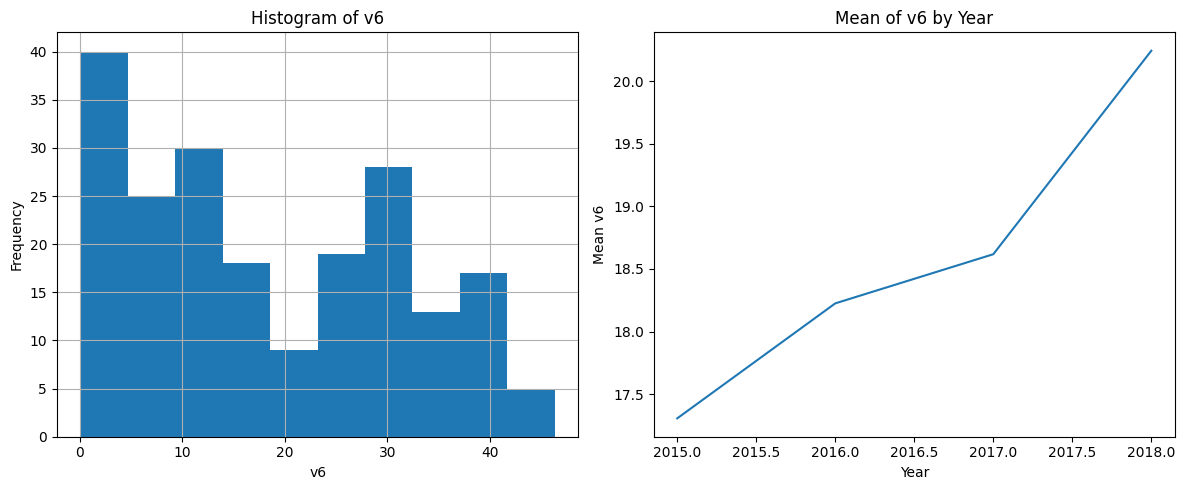

In [ ]:
variable_name = 'v6'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

#### v9: High-technology Exports as % of Manufactured Exports

Value Counts:
v9
0.960299     1
1.521006     1
11.669386    1
1.620850     1
11.854752    1
            ..
20.139387    1
23.389232    1
26.375985    1
8.021879     1
18.474054    1
Name: count, Length: 204, dtype: int64

Statistical Description:
count    204.000000
mean      12.336693
std       11.053020
min        0.181795
25%        5.054166
50%        9.114774
75%       17.810547
max       53.269670
Name: v9, dtype: float64


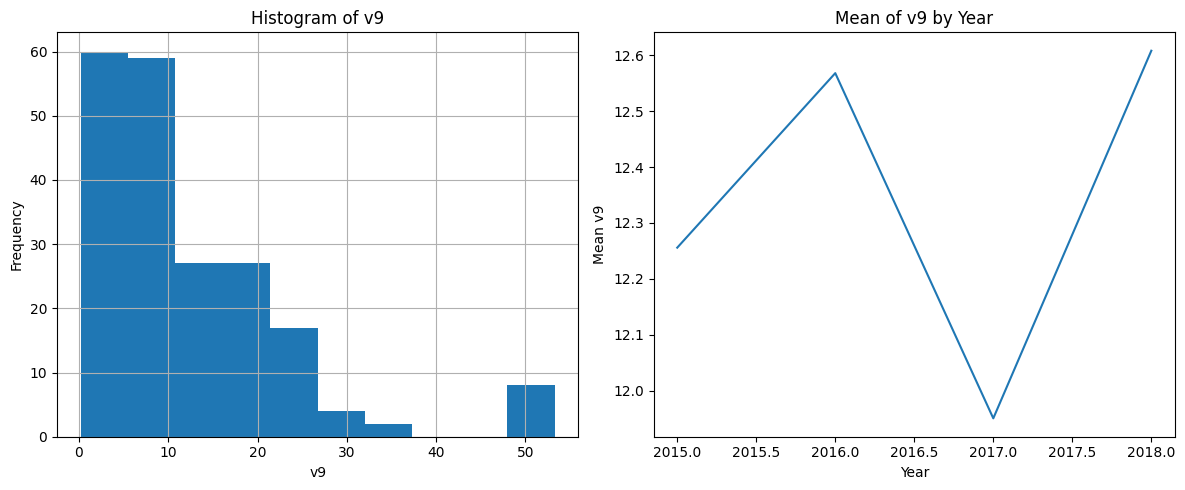

In [ ]:
variable_name = 'v9'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

#### v14: ICT service exports (BoP, current US$)

Value Counts:
v14
1.275640e+08    3
1.040312e+08    1
2.399913e+07    1
2.089920e+07    1
1.687498e+07    1
               ..
2.418982e+08    1
2.785483e+08    1
3.038177e+08    1
7.636846e+10    1
4.924700e+10    1
Name: count, Length: 202, dtype: int64

Statistical Description:
count    2.040000e+02
mean     6.203112e+09
std      1.363571e+10
min      1.636911e+07
25%      2.992394e+08
50%      9.839309e+08
75%      4.597812e+09
max      8.465543e+10
Name: v14, dtype: float64


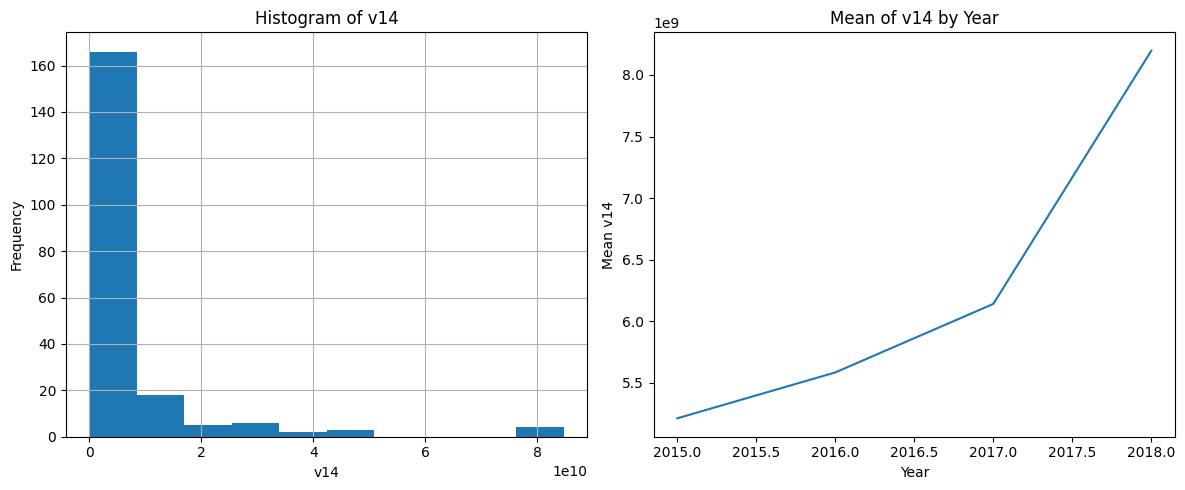

In [ ]:
variable_name = 'v14'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

#### v31: Gross domestic savings (% of GDP)

Value Counts:
v31
38.486829    1
35.861806    1
9.496764     1
8.054485     1
10.625586    1
            ..
26.888864    1
27.718939    1
26.226972    1
30.564428    1
18.576260    1
Name: count, Length: 204, dtype: int64

Statistical Description:
count    204.000000
mean      21.920900
std       10.729275
min       -1.944767
25%       16.375608
50%       22.292620
75%       27.801992
max       55.465775
Name: v31, dtype: float64


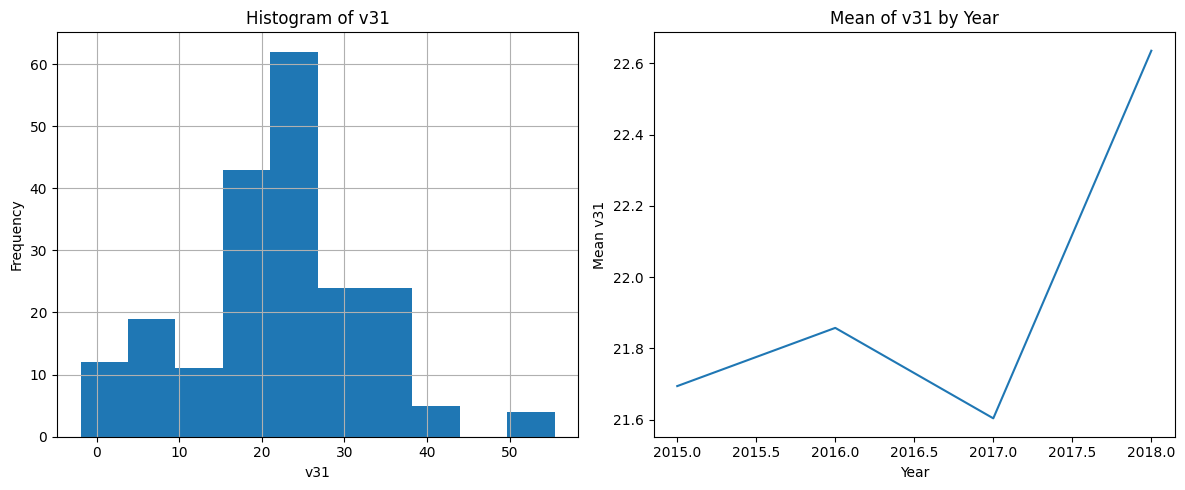

In [ ]:
variable_name = 'v31'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

#### v36: Current health expenditure (% of GDP)

Value Counts:
v36
6.279384     1
4.356716     1
6.716634     1
7.172411     1
7.759161     1
            ..
8.069790     1
8.097147     1
8.309081     1
3.595660     1
16.687105    1
Name: count, Length: 204, dtype: int64

Statistical Description:
count    204.000000
mean       7.164832
std        2.646330
min        2.639473
25%        5.238558
50%        7.164417
75%        8.920068
max       16.844324
Name: v36, dtype: float64


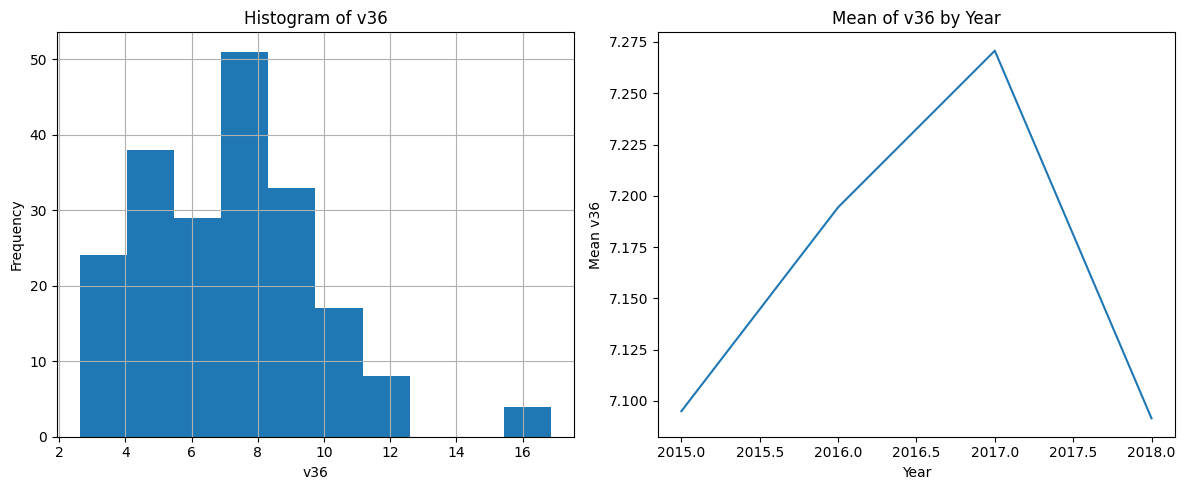

In [ ]:
variable_name = 'v36'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

#### v37: Mortality rate, under-5 (per 1,000 live births)

Value Counts:
v37
3.3     6
3.9     5
3.8     5
3.6     5
4.4     4
       ..
2.3     1
18.0    1
18.6    1
19.2    1
6.5     1
Name: count, Length: 132, dtype: int64

Statistical Description:
count    204.000000
mean      14.302941
std       16.340584
min        2.100000
25%        4.300000
50%        8.650000
75%       15.550000
max       84.000000
Name: v37, dtype: float64


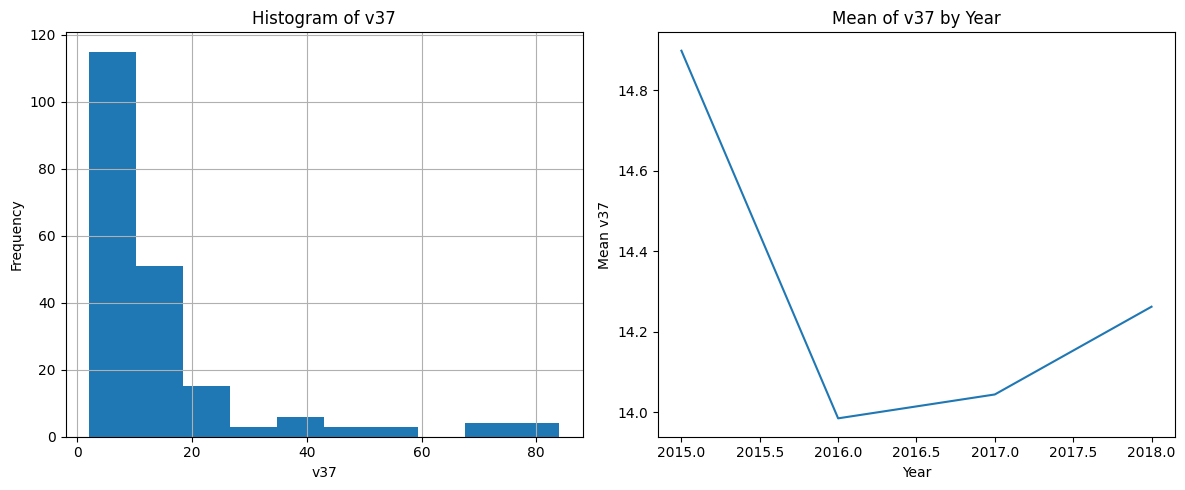

In [ ]:
variable_name = 'v37'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

#### v38: Life expectancy at birth, total (years)

Value Counts:
v38
81.900000    3
82.626829    2
78.539024    2
81.256098    2
81.124390    2
            ..
82.204878    1
82.660976    1
68.607000    1
68.897000    1
78.639024    1
Name: count, Length: 198, dtype: int64

Statistical Description:
count    204.000000
mean      76.224532
std        5.467803
min       57.206000
25%       74.093000
50%       76.387500
75%       81.132317
max       84.210976
Name: v38, dtype: float64


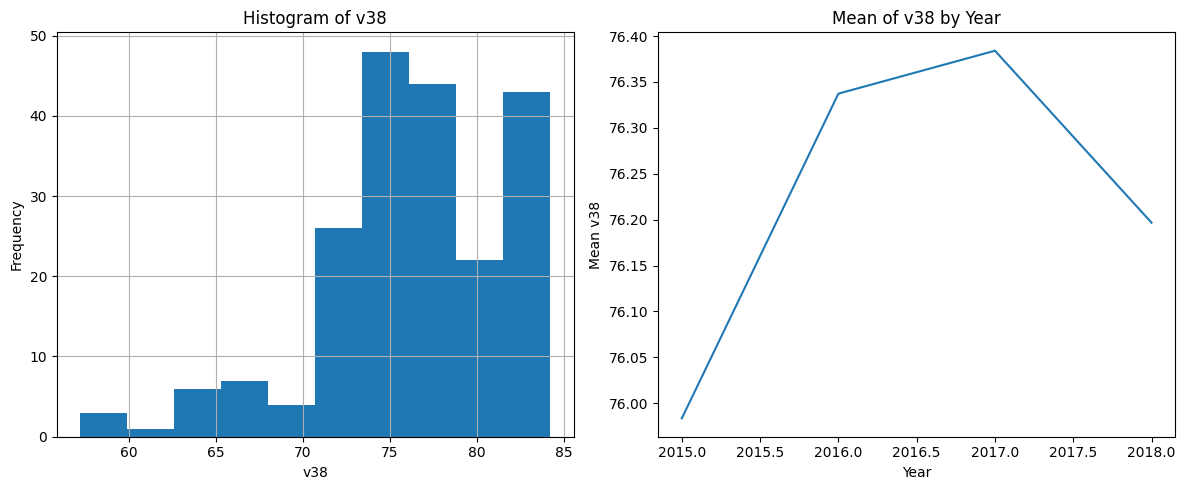

In [ ]:
variable_name = 'v38'

print("Value Counts:")
print(df[variable_name].value_counts())

print("\nStatistical Description:")
print(df[variable_name].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[variable_name].hist(bins=10)
plt.title(f'Histogram of {variable_name}')
plt.xlabel(variable_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('year')[variable_name].mean().plot()
plt.title(f'Mean of {variable_name} by Year')
plt.xlabel('Year')
plt.ylabel(f'Mean {variable_name}')

plt.tight_layout()
plt.show()

## Hypotheses

**Fixed Broadband Subscriptions (v6)**
- (H0): There is no relationship between Fixed Broadband Subscriptions and GDP per capita.
- (H1): There is a significant relationship between Fixed Broadband Subscriptions and GDP per capita.


**High-technology Exports as % of Manufactured Exports (v9)**
- (H0): There is no relationship between High-technology Exports as % of Manufactured Exports and GDP per capita.
- (H1): There is a significant relationship between High-technology Exports as % of Manufactured Exports and GDP per capita.


**ICT Service Exports (v14)**
- (H0): There is no relationship between ICT Service Exports and GDP per capita.
- (H1): There is a significant relationship between ICT Service Exports and GDP per capita.


**Gross Domestic Savings (% of GDP) (v31)**
- (H0): There is no relationship between Gross Domestic Savings (% of GDP) and GDP per capita.
- (H1): There is a significant relationship between Gross Domestic Savings (% of GDP) and GDP per capita.


**Current Health Expenditure (% of GDP) (v36)**
- (H0): There is no relationship between Current Health Expenditure (% of GDP) and GDP per capita.
- (H1): There is a significant relationship between Current Health Expenditure (% of GDP) and GDP per capita.


**Mortality Rate, Under-5 (per 1,000 live births) (v37)**
- (H0): There is no relationship between Mortality Rate, Under-5 and GDP per capita.
- (H1): There is a significant relationship between Mortality Rate, Under-5 and GDP per capita.


**Life Expectancy at Birth, Total (Years) (v38)**
- (H0): There is no relationship between Life Expectancy at Birth and GDP per capita.
- (H1): There is a significant relationship between Life Expectancy at Birth and GDP per capita.


## Pooled model

In [ ]:
import statsmodels.api as sm
from linearmodels.panel import PooledOLS

exog_vars = ['v6', 'v9', 'v14', 'v31', 'v36', 'v37', 'v38']
exog = sm.add_constant(df[exog_vars])
mod = PooledOLS(df["v30"], exog)
pooled_res = mod.fit()
print(pooled_res)

                          PooledOLS Estimation Summary                          
Dep. Variable:                    v30   R-squared:                        0.8153
Estimator:                  PooledOLS   R-squared (Between):              0.8072
No. Observations:                 204   R-squared (Within):              -2.1314
Date:                Sat, Nov 23 2024   R-squared (Overall):              0.8153
Time:                        22:18:48   Log-likelihood                   -2130.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      123.62
Entities:                          60   P-value                           0.0000
Avg Obs:                       3.4000   Distribution:                   F(7,196)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             123.62
                            

In [ ]:
coefs = pd.DataFrame()
coefs['Coefs'] = pooled_res.params[1:]
coefs['Features'] = pooled_res.params.index[1:]
coefs.set_index('Features', inplace=True)
print('Intercept = ', pooled_res.params[0])
coefs['OddsRatio'] = np.exp(coefs.Coefs)
coefs

Intercept =  -136617.06471855825


,Coefs,OddsRatio
Features,,
v6,5.784559e+02,1.660448e+251
v9,2.049842e+02,1.055581e+89
v14,7.326456e-08,1.000000e+00
v31,4.504449e+02,4.224252e+195
v36,2.513050e+03,inf
v37,4.131976e+02,2.814619e+179
v38,1.418099e+03,inf


In [ ]:
def process_coefs(coefs):
    for feature, coef, odds_ratio in zip(coefs.index, coefs["Coefs"], coefs["OddsRatio"]):
        print(f"{feature}: Coefficient = {coef:.6f}, OddsRatio = {odds_ratio:.6f}")

print("Intercept = ", pooled_res.params[0])
process_coefs(coefs)

Intercept =  -136617.06471855825
v6: Coefficient = 578.455946, OddsRatio = 166044807943349952897022511455509889898491189286019319094512454157181742167237693554850319554686200788452644856568490240219087588439144880842808094809083498040728554766198219748934088367171762240671783097327251135506075501778187718184569613811546324992.000000
v9: Coefficient = 204.984165, OddsRatio = 105558110638128577511474747161927490159758573632474412596150989001970881627713919856410624.000000
v14: Coefficient = 0.000000, OddsRatio = 1.000000
v31: Coefficient = 450.444935, OddsRatio = 4224251998876639642945545462610681538052777371394923072040285558145864321842850005645802206319713746739650091281876204565577463234722602438582861769829807711116208349114585917664580617876524761088.000000
v36: Coefficient = 2513.049800, OddsRatio = inf
v37: Coefficient = 413.197558, OddsRatio = 28146187533187175133640601558948879223622865537352452379598314153042752500072762754832148484864425635978105492544800057899748032041632472

## Fixed effect model

In [ ]:
from linearmodels.panel import PanelOLS

exog_vars = ['v6', 'v9', 'v14', 'v31', 'v36', 'v37', 'v38']
exog = sm.add_constant(df[exog_vars])
mod = PanelOLS(df["v30"], exog, entity_effects=True)
fe_res = mod.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    v30   R-squared:                        0.5002
Estimator:                   PanelOLS   R-squared (Between):              0.3194
No. Observations:                 204   R-squared (Within):               0.5002
Date:                Sat, Nov 23 2024   R-squared (Overall):              0.3187
Time:                        22:18:48   Log-likelihood                   -1524.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      19.590
Entities:                          60   P-value                           0.0000
Avg Obs:                       3.4000   Distribution:                   F(7,137)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             19.590
                            

## Random effect model

In [ ]:
from linearmodels.panel import RandomEffects

mod = RandomEffects(df["v30"], exog)
re_res = mod.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:                    v30   R-squared:                        0.4677
Estimator:              RandomEffects   R-squared (Between):              0.5197
No. Observations:                 204   R-squared (Within):               0.4169
Date:                Sat, Nov 23 2024   R-squared (Overall):              0.5157
Time:                        22:18:48   Log-likelihood                   -1601.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      24.603
Entities:                          60   P-value                           0.0000
Avg Obs:                       3.4000   Distribution:                   F(7,196)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             24.647
                            

## Selection of a suitable Panel Data Model

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
residuals_pooled_OLS = pooled_res.resids
pooled_OLS_dataset = pd.concat([df, residuals_pooled_OLS], axis=1)
breusch_pagan_test_results = het_breuschpagan(pooled_OLS_dataset['residual'], exog)
print('P-value:', breusch_pagan_test_results[3])

P-value: 2.2042513058150837e-12


**H0:** no individual effects (test significance greater than 0.05)


H0 is rejected as p-value < 0.05 => there are individual effects => we should select a model with effects (fixed or random).

In [ ]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    b = fe.params
    B = re.params
    v_b = fe.cov
    v_B = re.cov
    df = b[np.abs(b) < 1e8].size
    chi2 = np.dot((b - B).T, la.inv(v_b - v_B).dot(b - B))
    pval = stats.chi2.sf(chi2, df)
    return chi2, df, pval

hausman_results = hausman(fe_res, re_res)
print('p-value: ' + str(hausman_results[2]))

p-value: 1.0


**H0:** individual effects and regressors are not correlated (they are random)


H0 is not rejected as p-value > 0.05 => individual effects and regressors are not correlated => we select the random-effects model.

## Description of resulting model

The results of the random effects model show that v6 (Fixed Broadband Subscriptions), v14 (ICT Service Exports), v37 (Mortality Rate, Under-5) and v38 (Life Expectancy at Birth) have a significant effect on GDP per capita as their p-value is less than 0.05. The model explains about 51.57% of the variation in GDP (R-squared Overall = 0.5157).

Some variables such as v9 (High-technology Exports) and v31 (Gross Domestic Savings) are insignificant as their p-value is greater than 0.05. The variable v36 (Health Expenditure) is almost significant (p-value ≈ 0.0957).

The model as a whole is statistically significant as confirmed by the F-statistic with p-value = 0.0000. It is suitable for analyzing the impact of selected factors on GDP.


## Description of the relationship between dependent variable and predictors

**The number of fixed broadband subscribers (v6)** has a significant positive impact on GDP per capita. An increase in the number of subscribers is associated with economic growth.


**Exports of high-tech products (v9)** do not have a significant impact on GDP per capita in this model. This may be due to the small volume of such exports or other factors.


**Exports of ICT services (v14)** have a strong positive impact on GDP. More ICT exports are associated with a higher level of the economy.


**Gross domestic savings (v31)** do not have a significant effect on GDP per capita. Their effect may depend on how they are used for investment.


**Health expenditures (v36)** have a positive effect, but it is insignificant. Their contribution to the economy may be less visible or depend on other factors.


**The under-5 mortality rate (v37)** has a significant negative impact on GDP. High child mortality is associated with poor economic performance.


**Life expectancy (v38)** has a strong positive effect on GDP. Long life expectancy is associated with economic growth.

## Analysis Conclusion

The analysis showed that economic development, measured through GDP per capita, is closely related to factors such as broadband connectivity, exports of ICT services, life expectancy and infant mortality. These variables were found to be the most significant, confirming their importance to the economy. In contrast, exports of high-tech products, gross savings and health expenditure showed a weak or insignificant relationship, which may be due to the characteristics of the data or the influence of other factors. The random effects model chosen on the basis of the tests showed high explanatory power and statistical significance, confirming the reliability of the results.